In [11]:
import pandas as pd 
import sqlite3

In [12]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [13]:
query = """ 
SELECT datetime
FROM pageviews
WHERE uid LIKE "user_%"
"""

df = pd.read_sql(query, conn)

In [14]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [15]:
df['date'] = df['datetime'].dt.date

In [16]:
df.head()

,datetime,date
0,2020-04-17 22:46:26.785035,2020-04-17
1,2020-04-18 10:53:52.623447,2020-04-18
2,2020-04-18 10:56:55.833899,2020-04-18
3,2020-04-18 10:57:37.331258,2020-04-18
4,2020-04-18 12:05:48.200144,2020-04-18


In [17]:
count_day = df.groupby('date').count().reset_index()
count_day.rename(columns = {'datetime':'views'}, inplace=True)

In [18]:
count_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    33 non-null     object
 1   views   33 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 660.0+ bytes


C:\Users\Анастасия\AppData\Local\Temp\ipykernel_15392\2161509019.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


[Text(18369.0, 0, '2020-04-17'),
 Text(18373.0, 0, '2020-04-21'),
 Text(18377.0, 0, '2020-04-25'),
 Text(18381.0, 0, '2020-04-29'),
 Text(18383.0, 0, '2020-05-01'),
 Text(18387.0, 0, '2020-05-05'),
 Text(18391.0, 0, '2020-05-09'),
 Text(18395.0, 0, '2020-05-13'),
 Text(18399.0, 0, '2020-05-17'),
 Text(18403.0, 0, '2020-05-21')]

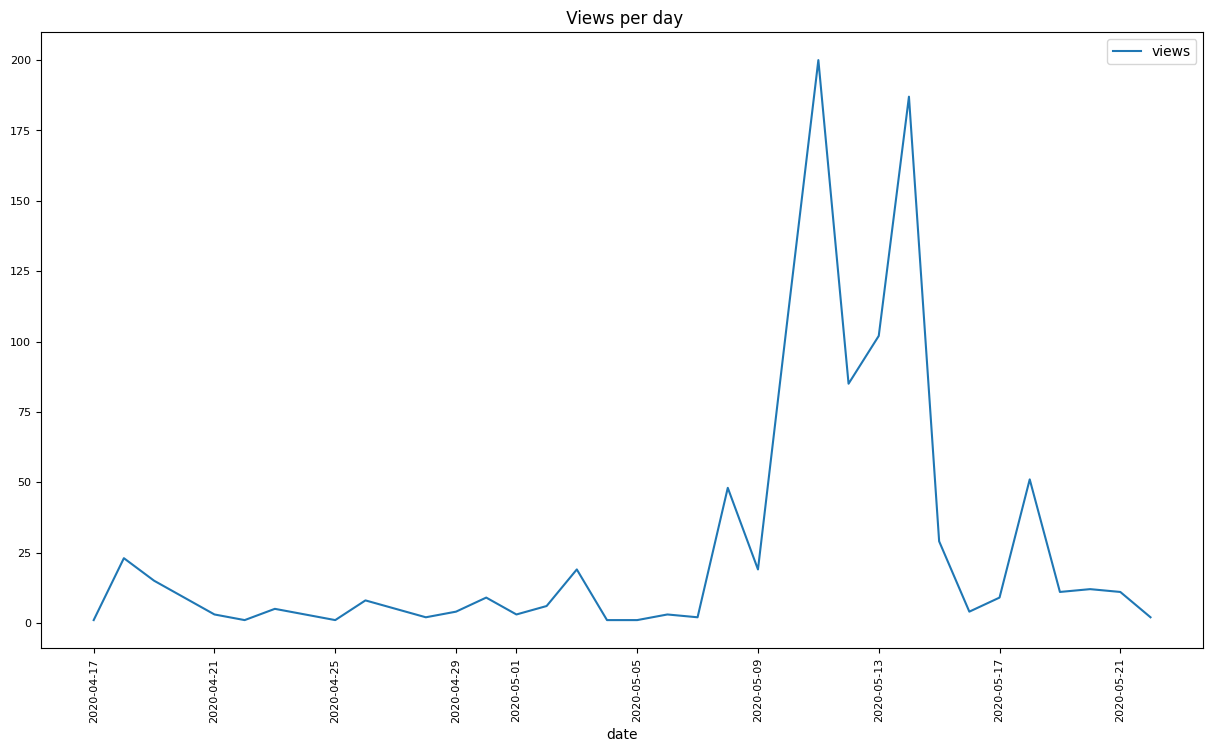

In [19]:
ax = count_day.plot(
    x = 'date',
    y = 'views',
    figsize=(15,8),
    title=' Views per day', 
    fontsize=8
)
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

In [20]:
conn.close()